In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
np.random.seed(42)

areas = np.random.randint(30, 150, 500)
rooms = np.random.randint(1, 5, 500)
floors = np.random.randint(1, 25, 500)
districts = np.random.choice([1, 2, 3], 500)

price = (
    areas * 800 +
    rooms * 5000 +
    floors * 300 +
    districts * 10000 +
    np.random.randint(-10000, 10000, 500)
)

df = pd.DataFrame({
    "area": areas,
    "rooms": rooms,
    "floor": floors,
    "district": districts,
    "price": price
})

df.head()

,area,rooms,floor,district,price
0,132,1,17,3,136836
1,81,4,13,3,110764
2,122,2,1,3,134909
3,44,3,2,2,73787
4,136,1,9,2,131043


In [4]:
df.to_csv("apartment_price.csv", index=False)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   area      500 non-null    int32
 1   rooms     500 non-null    int32
 2   floor     500 non-null    int32
 3   district  500 non-null    int32
 4   price     500 non-null    int32
dtypes: int32(5)
memory usage: 9.9 KB


In [4]:
df.describe()

,area,rooms,floor,district,price
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,88.940000,2.446000,12.180000,1.986000,106807.878000
std,35.188191,1.160076,7.080669,0.821678,30113.398554
min,30.000000,1.000000,1.000000,1.000000,34819.000000
25%,59.000000,1.000000,6.000000,1.000000,83459.750000
50%,89.000000,2.000000,12.000000,2.000000,106148.500000
75%,121.000000,4.000000,19.000000,3.000000,132590.250000
max,149.000000,4.000000,24.000000,3.000000,174007.000000


In [5]:
df["price"].mean()

106807.878

In [6]:
df.isnull().sum()

area        0
rooms       0
floor       0
district    0
price       0
dtype: int64

In [7]:
X = df[["area", "rooms", "floor", "district"]]
y = df["price"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

LinearRegression()

In [11]:
predictions = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, predictions)
print("MAE: ", mae)

MAE:  4591.221901016829


In [13]:
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 28945763.07504059


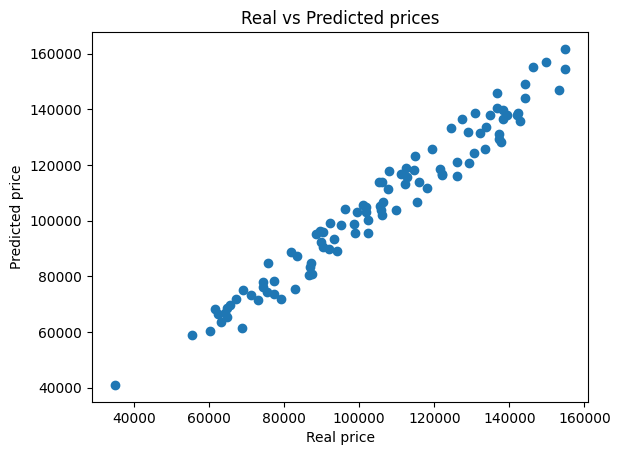

In [14]:
plt.scatter(y_test, predictions)
plt.xlabel("Real price")
plt.ylabel("Predicted price")
plt.title("Real vs Predicted prices")
plt.show()

In [15]:
model.coef_

array([  801.27484987,  4963.4547632 ,   303.89253262, 10088.52813278])

In [16]:
new_data = pd.DataFrame([[80, 3, 10, 2]], columns=["area", "rooms", "floor", "district"])

In [17]:
model.predict(new_data)

array([102011.98872153])

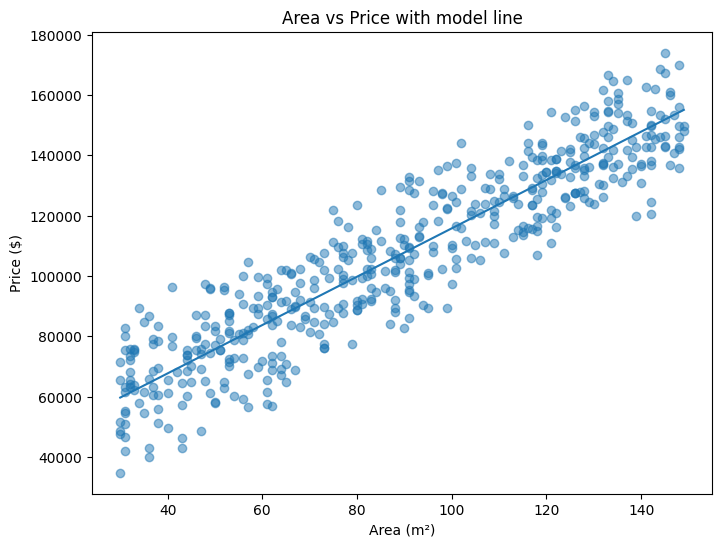

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(df["area"], df["price"], alpha=0.5)

x_line = np.linspace(df["area"].min(), df["area"].max(), 100)

rooms_mean = df["rooms"].mean()
floor_mean = df["floor"].mean()
district_mean = df["district"].mean()

X_line = pd.DataFrame({
    "area": x_line,
    "rooms": rooms_mean,
    "floor": floor_mean,
    "district": district_mean
})

y_line = model.predict(X_line)

plt.plot(x_line, y_line)
plt.xlabel("Area (m²)")
plt.ylabel("Price ($)")
plt.title("Area vs Price with model line")
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(df["experience"], df["salary"], alpha=0.5)

x_line = np.linspace(df["experience"].min(), df["experience"].max(), 100)

projects_mean = df["projects"].mean()

X_line = pd.DataFrame({
    "experience": x_line,
    "projects": projects_mean,
    "english_level": 3
})

y_line = model.predict(X_line)
plt.plot(x_line, y_line)
plt.xlabel("Experience (m²)")
plt.ylabel("Salary ($)")
plt.title("Experience vs Salary with model line")
plt.show()